In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DATA_DIR  = '/content/drive/MyDrive/hackathon/'        # <-- change this
MODEL_DIR = '/content/drive/MyDrive/hackathon/models/'
PLOT_DIR  = '/content/drive/MyDrive/hackathon/plots/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

In [3]:
!pip install fair-esm shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.1 MB/s eta 0:00:00


In [4]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
# T4 GPU  -> safe batch_size = 16
# A100    -> safe batch_size = 32
# CPU     -> batch_size = 4 (slow but works)

GPU available: True
Device: Tesla T4


# Example script for Hackathon

Within each cycle of active learning, you can:

1. Collect training data (original training data + your query data).

2. Train a prediction model to predict the DMS_score for each mutant (e.g., M0A).

3. Use the trained model to predict the score for all mutant in the test set.

4. Select query mutants for next round based on certain criteria. You may want to make sure you don't query the same mutant twice as you only have a limited chances of making queries in total.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
import random
from copy import deepcopy
import pandas as pd
from scipy.stats import spearmanr
import argparse
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Set a Random Seed

In [6]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

## 1. collect training data

Upload `sequence.fasta`, `train.csv`, and `test.csv` to the current runtime:

1. click the folder icon on the left

2. click the upload icon and upload the files to the current directory

In [9]:
with open('Hackathon_data/sequence.fasta', 'r') as f:
  data = f.readlines()

sequence_wt = data[1].strip()
sequence_wt

'MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLREKMRRRLESGDKWFSLEFFPPRTAEGAVNLISRFDRMAAGGPLYIDVTWHPAGDPGSDKETSSMMIASTAVNYCGLETILHMTCCRQRLEEITGHLHKAKQLGLKNIMALRGDPIGDQWEEEEGGFNYAVDLVKHIRSEFGDYFDICVAGYPKGHPEAGSFEADLKHLKEKVSAGADFIITQLFFEADTFFRFVKACTDMGITCPIVPGIFPIQGYHSLRQLVKLSKLEVPQEIKDVIEPIKDNDAAIRNYGIELAVSLCQELLASGLVPGLHFYTLNREMATTEVLKRLGMWTEDPRRPLPWALSAHPKRREEDVRPIFWASRPKSYIYRTQEWDEFPNGRWGNSSSPAFGELKDYYLFYLKSKSPKEELLKMWGEELTSEESVFEVFVLYLSGEPNRNGHKVTCLPWNDEPLAAETSLLKEELLRVNRQGILTINSQPNINGKPSSDPIVGWGPSGGYVFQKAYLEFFTSRETAEALLQVLKKYELRVNYHLVNVKGENITNAPELQPNAVTWGIFPGREIIQPTVVDPVSFMFWKDEAFALWIERWGKLYEEESPSRTIIQYIHDNYFLVNLVDNDFPLDNCLWQVVEDTLELLNRPTQNARETEAP'

In [10]:
len(sequence_wt)

656

In [11]:
def get_mutated_sequence(mut, sequence_wt):
  wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]

  sequence = deepcopy(sequence_wt)

  return sequence[:pos]+mt+sequence[pos+1:]

In [12]:
df_train = pd.read_csv('Hackathon_data/train.csv')
df_train['sequence'] = df_train.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_train

,mutant,DMS_score,sequence
0,M0Y,0.2730,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.2857,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.2153,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.3122,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.2180,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1135,P347D,0.3876,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1136,P347C,0.1837,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1137,P347A,0.4611,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1138,P347M,0.2412,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [13]:
df_test = pd.read_csv('Hackathon_data/test.csv')
df_test['sequence'] = df_test.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test

,mutant,sequence
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


### Quick EDA
**Exploratory Data Analysis to understand fitness distribution and mutation coverage**

Train size: 1140
Test size: 11324

Fitness stats:
count    1140.000000
mean        0.225597
std         0.207202
min         0.006700
25%         0.061650
50%         0.156750
75%         0.330400
max         0.995700
Name: DMS_score, dtype: float64


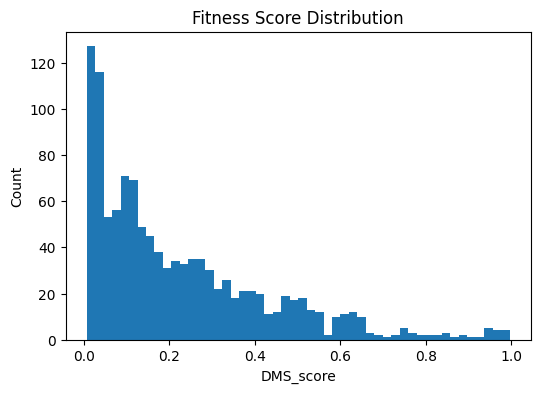

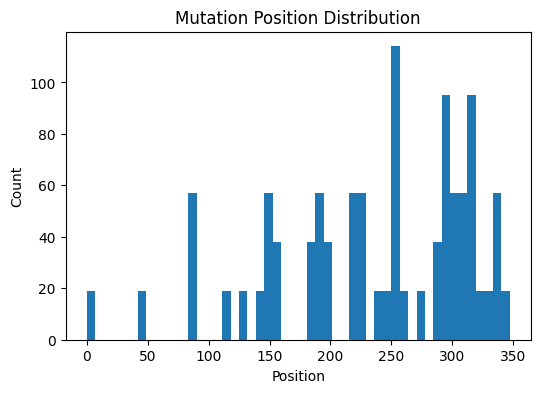


Missing values in train:
mutant       0
DMS_score    0
sequence     0
dtype: int64

Missing values in test:
mutant      0
sequence    0
dtype: int64


In [14]:
print("Train size:", len(df_train))
print("Test size:", len(df_test))

print("\nFitness stats:")
print(df_train['DMS_score'].describe())

positions = df_train['mutant'].apply(lambda x: int(x[1:-1]))

plt.figure(figsize=(6, 4))
plt.hist(df_train['DMS_score'], bins=50)
plt.title("Fitness Score Distribution")
plt.xlabel("DMS_score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(positions, bins=50)
plt.title("Mutation Position Distribution")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

print("\nMissing values in train:")
print(df_train.isnull().sum())
print("\nMissing values in test:")
print(df_test.isnull().sum())

In [15]:
# from sklearn.model_selection import train_test_split
# from scipy.stats import spearmanr
# import numpy as np
# import pandas as pd

#Sequence distribution
train_seq_lengths = df_train["sequence"].apply(len)
test_seq_lengths = df_test["sequence"].apply(len)

print("Sequence length summary (train):")
print(train_seq_lengths.describe())

print("\nSequence length summary (test):")
print(test_seq_lengths.describe())

print("\nUnique sequence lengths in train:", sorted(train_seq_lengths.unique()))
print("Unique sequence lengths in test:", sorted(test_seq_lengths.unique()))

#Fitness score range
print("\nFitness score range:")
print("Min fitness:", df_train["DMS_score"].min())
print("Max fitness:", df_train["DMS_score"].max())
print("Mean fitness:", df_train["DMS_score"].mean())
print("Median fitness:", df_train["DMS_score"].median())

#Missing data check
print("\nMissing values in train:")
print(df_train[["mutant", "sequence", "DMS_score"]].isnull().sum())

print("\nMissing values in test:")
print(df_test[["mutant", "sequence"]].isnull().sum())

#Train/validation split summary
df_train_split, val_df_split = train_test_split(df_train, test_size=0.2, random_state=42)

print("\nTrain/Validation split summary:")
print("Train split size:", len(df_train_split))
print("Validation split size:", len(val_df_split))
print("Train split percentage:", round(len(df_train_split) / len(df_train), 3))
print("Validation split percentage:", round(len(val_df_split) / len(df_train), 3))

#Mutation position coverage in train vs val
train_positions = df_train_split["mutant"].apply(lambda x: int(x[1:-1]))
val_positions = val_df_split["mutant"].apply(lambda x: int(x[1:-1]))

print("\nMutation position coverage:")
print("Train unique positions:", train_positions.nunique())
print("Validation unique positions:", val_positions.nunique())

Sequence length summary (train):
count    1140.0
mean      656.0
std         0.0
min       656.0
25%       656.0
50%       656.0
75%       656.0
max       656.0
Name: sequence, dtype: float64

Sequence length summary (test):
count    11324.0
mean       656.0
std          0.0
min        656.0
25%        656.0
50%        656.0
75%        656.0
max        656.0
Name: sequence, dtype: float64

Unique sequence lengths in train: [np.int64(656)]
Unique sequence lengths in test: [np.int64(656)]

Fitness score range:
Min fitness: 0.0067
Max fitness: 0.9957
Mean fitness: 0.22559728070175433
Median fitness: 0.15675

Missing values in train:
mutant       0
sequence     0
DMS_score    0
dtype: int64

Missing values in test:
mutant      0
sequence    0
dtype: int64

Train/Validation split summary:
Train split size: 912
Validation split size: 228
Train split percentage: 0.8
Validation split percentage: 0.2

Mutation position coverage:
Train unique positions: 60
Validation unique positions: 60


In [ ]:
# TODO: integrate the query data that you acquired each round into df_train

## 2. Train a prediction model [PREVIOUS CODE]

Here, we provided a linear regression model and used one-hot encoding to encode each variant. You would need to build your own model to achieve better performances.

Hint: you can perform cross-validation on the training set to evaluate your predictor before making predictions on the test set.

In [16]:
'''hyperparameters'''

seq_length = 656
seed = 0 # seed for splitting the validation set
val_ratio = 0.2 # proportion of validation set

In [17]:
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}

def encode_mutation(mut, seq_length=656):
    """ 'ACD' --> [[1,0,0..],[0,1,0,..],[0,0,1,0,..]]"""
    wt_aa, pos, mut_aa = mut[0], int(mut[1:-1]), mut[-1]
    vec = []
    # Position (normalized)
    vec.append(pos / seq_length)
    # WT amino acid (one-hot, 20)
    wt_oh = [0.0] * 20
    if wt_aa in aa_to_idx: wt_oh[aa_to_idx[wt_aa]] = 1.0
    vec.extend(wt_oh)
    # Mutant amino acid (one-hot, 20)
    mt_oh = [0.0] * 20
    if mut_aa in aa_to_idx: mt_oh[aa_to_idx[mut_aa]] = 1.0
    vec.extend(mt_oh)

    return np.array(vec, dtype=np.float32)

class ProteinDataset(Dataset):
    def __init__(self, df, istrain=True):
        self.encodings = np.stack([encode_mutation(m) for m in df['mutant'].values])
        self.targets = df['DMS_score'].values.astype(np.float32) if istrain else np.zeros(len(df), dtype=np.float32)

    def __len__(self): return len(self.encodings)
    def __getitem__(self, idx): return torch.tensor(self.encodings[idx]), torch.tensor(self.targets[idx])

In [18]:
train_dataset = ProteinDataset(df_train)
test_dataset = ProteinDataset(df_test, istrain=False)

# split validation set
train_dataset, val_dataset = train_test_split(train_dataset, test_size=val_ratio, random_state=seed, shuffle=True)

# TODO: revise according to your own model
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import numpy as np

X_train = np.stack([x[0].numpy() for x in train_dataset])
y_train = np.array([x[1].numpy() for x in train_dataset])
X_val   = np.stack([x[0].numpy() for x in val_dataset])
y_val   = np.array([x[1].numpy() for x in val_dataset])
X_test  = np.stack([x[0].numpy() for x in test_dataset])

# Combine train and val for final training to get maximum data
X_full_train = np.concatenate([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

# Train a Gradient Boosting Regressor and evaluate on validation set
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gbr.fit(X_train, y_train)

val_preds = gbr.predict(X_val)
val_spearman = spearmanr(y_val, val_preds)[0]
print(f"Gradient Boosting val Spearman: {val_spearman:.4f}")

# Retrain on full training data for final test predictions
gbr.fit(X_full_train, y_full_train)
y_test_pred_gbr = gbr.predict(X_test)
print("Predictions generated for test set.")

Gradient Boosting val Spearman: 0.4065
Predictions generated for test set.


## Additional model comparison [OLD CODE]

### Ridge
**Train a Ridge Regression baseline for comparison against the existing Gradient Boosting model**

In [21]:
# Train Ridge Regression on the same train/validation split for comparison
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_test_pred_ridge = ridge_model.predict(X_val)
ridge_spearman = spearmanr(y_val, y_test_pred_ridge)[0]

print(f"Ridge Regression val Spearman: {ridge_spearman:.4f}")

Ridge Regression val Spearman: 0.2022


### ESM-2

In [22]:
!pip install fair-esm torch pandas numpy scikit-learn scipy

# [CURRENT CODE]

In [23]:
try:
    esm_train = np.load(f'{MODEL_DIR}esm_train_embeddings.npy')
    esm_test  = np.load(f'{MODEL_DIR}esm_test_embeddings.npy')
    print(f"Loaded: train {esm_train.shape}, test {esm_test.shape}")
except FileNotFoundError:
    print("Not found — run extraction first.")

Not found — run extraction first.


In [24]:
# Each amino acid gets 5 biologically meaningful numbers:
# [hydrophobicity, charge, size (mol weight), polarity, aromaticity]
# Source: standard biochemistry lookup tables
AA_PROPERTIES = {
    'A': [1.8,  0.0, 89.1,  0.0, 0.0],
    'C': [2.5,  0.0, 121.2, 0.0, 0.0],
    'D': [-3.5, -1.0, 133.1, 1.0, 0.0],
    'E': [-3.5, -1.0, 147.1, 1.0, 0.0],
    'F': [2.8,  0.0, 165.2, 0.0, 1.0],
    'G': [-0.4, 0.0, 75.0,  0.0, 0.0],
    'H': [-3.2, 0.5, 155.2, 1.0, 1.0],
    'I': [4.5,  0.0, 131.2, 0.0, 0.0],
    'K': [-3.9, 1.0, 146.2, 1.0, 0.0],
    'L': [3.8,  0.0, 131.2, 0.0, 0.0],
    'M': [1.9,  0.0, 149.2, 0.0, 0.0],
    'N': [-3.5, 0.0, 132.1, 1.0, 0.0],
    'P': [-1.6, 0.0, 115.1, 0.0, 0.0],
    'Q': [-3.5, 0.0, 146.2, 1.0, 0.0],
    'R': [-4.5, 1.0, 174.2, 1.0, 0.0],
    'S': [-0.8, 0.0, 105.1, 1.0, 0.0],
    'T': [-0.7, 0.0, 119.1, 1.0, 0.0],
    'V': [4.2,  0.0, 117.1, 0.0, 0.0],
    'W': [-0.9, 0.0, 204.2, 0.0, 1.0],
    'Y': [-1.3, 0.0, 181.2, 1.0, 1.0],
}

def encode_mutation_rich(mut, seq_length=656):
    """
    Richer feature vector for a single mutation string like 'A100M'.

    Features:
      - Normalized position (1)
      - WT amino acid: one-hot (20) + physicochemical (5)
      - Mutant amino acid: one-hot (20) + physicochemical (5)
      - DIFFERENCE in physicochemical properties (5)  <-- new, captures the change
      - Is same amino acid class? (polar->polar, charged->charged etc.) (1)

    Total: 1 + 25 + 25 + 5 + 1 = 57 features
    """
    wt_aa = mut[0]
    pos = int(mut[1:-1])
    mut_aa = mut[-1]

    vec = []

    # Position (normalized)
    vec.append(pos / seq_length)

    # WT one-hot
    wt_oh = [0.0] * 20
    if wt_aa in aa_to_idx:
        wt_oh[aa_to_idx[wt_aa]] = 1.0
    vec.extend(wt_oh)

    # WT physicochemical
    wt_phys = AA_PROPERTIES.get(wt_aa, [0.0] * 5)
    vec.extend(wt_phys)

    # Mutant one-hot
    mt_oh = [0.0] * 20
    if mut_aa in aa_to_idx:
        mt_oh[aa_to_idx[mut_aa]] = 1.0
    vec.extend(mt_oh)

    # Mutant physicochemical
    mt_phys = AA_PROPERTIES.get(mut_aa, [0.0] * 5)
    vec.extend(mt_phys)

    # Difference in physicochemical (mutation effect signature)
    diff = [mt - wt for mt, wt in zip(mt_phys, wt_phys)]
    vec.extend(diff)

    # Same charge class? (1 if both charged or both neutral)
    wt_charged = abs(wt_phys[1]) > 0.1
    mt_charged = abs(mt_phys[1]) > 0.1
    vec.append(1.0 if wt_charged == mt_charged else 0.0)

    return np.array(vec, dtype=np.float32)

def get_esm2_embeddings(sequences, mutations, batch_size=16, layer=33):
    """
    Extract per-mutation embeddings from ESM-2 (esm2_t33_650M_UR50D).

    What this does:
      - Feeds each full protein sequence into ESM-2
      - Extracts the embedding at the mutated position only
      - This gives a 1280-dimensional vector that captures the
        local context around the mutation site

    Args:
        sequences: list of full protein sequences (strings)
        mutations:  list of mutation strings like 'A100M'
        batch_size: how many sequences to process at once (lower if OOM)
        layer:      which transformer layer to extract from (33 = last)

    Returns:
        np.array of shape (n_samples, 1280)
    """
    try:
        import esm
        print("ESM-2 loaded successfully.")
    except ImportError:
        print("ESM not installed. Run: pip install fair-esm")
        print("Falling back to rich physicochemical features only.")
        return None

    model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
    batch_converter = alphabet.get_batch_converter()
    model.eval()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"ESM-2 running on: {device}")

    all_embeddings = []

    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i:i + batch_size]
        batch_muts = mutations[i:i + batch_size]

        # ESM expects list of (label, sequence) tuples
        data = [(f"seq_{j}", seq) for j, seq in enumerate(batch_seqs)]
        _, _, batch_tokens = batch_converter(data)
        batch_tokens = batch_tokens.to(device)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[layer], return_contacts=False)

        token_embeddings = results["representations"][layer]  # (batch, seq_len+2, 1280)

        # Extract embedding at the mutated position for each sample
        for k, mut in enumerate(batch_muts):
            pos = int(mut[1:-1])  # e.g. 'A100M' -> 100
            # ESM tokens: position 0 is <cls>, so mutated residue is at pos+1
            emb = token_embeddings[k, pos, :].cpu().numpy()
            all_embeddings.append(emb)

        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i + batch_size, len(sequences))}/{len(sequences)} sequences")

    return np.array(all_embeddings, dtype=np.float32)

def build_features(df, esm_embeddings=None, is_train=True):
    """
    Combine rich hand-crafted features with ESM-2 embeddings (if available).

    If ESM embeddings are provided, they are concatenated with the
    physicochemical features. This tends to give the best results.
    """
    # Rich hand-crafted features (57-dim)
    hand_features = np.stack([
        encode_mutation_rich(m) for m in df['mutant'].values
    ])

    if esm_embeddings is not None:
        # Concatenate: (n, 57) + (n, 1280) = (n, 1337)
        features = np.concatenate([hand_features, esm_embeddings], axis=1)
        print(f"  Using combined features: {features.shape[1]} dims")
    else:
        features = hand_features
        print(f"  Using hand-crafted features only: {features.shape[1]} dims")

    return features

def spearman(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

def train_and_evaluate(X_train, y_train, X_val, y_val):
    """
    Train GradientBoosting and Ridge, evaluate with Spearman correlation.
    Returns both trained models and their scores.
    """
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)

    results = {}

    # --- Gradient Boosting ---
    print("\nTraining Gradient Boosting...")
    gb = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        min_samples_leaf=5,
        random_state=42
    )
    gb.fit(X_train_sc, y_train)
    gb_preds = gb.predict(X_val_sc)
    gb_spearman = spearman(y_val, gb_preds)
    print(f"  Gradient Boosting val Spearman: {gb_spearman:.4f}")
    results['gradient_boosting'] = {
        'model': gb, 'scaler': scaler,
        'val_spearman': gb_spearman, 'val_preds': gb_preds
    }

    # --- Ridge Regression ---
    print("\nTraining Ridge Regression...")
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_sc, y_train)
    ridge_preds = ridge.predict(X_val_sc)
    ridge_spearman = spearman(y_val, ridge_preds)
    print(f"  Ridge Regression val Spearman: {ridge_spearman:.4f}")
    results['ridge'] = {
        'model': ridge, 'scaler': scaler,
        'val_spearman': ridge_spearman, 'val_preds': ridge_preds
    }

    # --- Simple Ensemble (average) ---
    ensemble_preds = 0.6 * gb_preds + 0.4 * ridge_preds
    ens_spearman = spearman(y_val, ensemble_preds)
    print(f"\n  Ensemble (0.6 GB + 0.4 Ridge) val Spearman: {ens_spearman:.4f}")
    results['ensemble'] = {
        'val_spearman': ens_spearman, 'val_preds': ensemble_preds
    }

    return results

In [25]:
USE_ESM = True  # Set to True if you have GPU and fair-esm installed

esm_train = None
esm_test = None

if USE_ESM:
    print("\nExtracting ESM-2 embeddings for train set...")
    esm_train = get_esm2_embeddings(
        sequences=df_train['sequence'].tolist(),
        mutations=df_train['mutant'].tolist(),
        batch_size=8  # lower this if you get out-of-memory errors
    )
    print("\nExtracting ESM-2 embeddings for test set...")
    esm_test = get_esm2_embeddings(
        sequences=df_test['sequence'].tolist(),
        mutations=df_test['mutant'].tolist(),
        batch_size=8
    )
    # Save so you don't have to recompute
    if esm_train is not None:
        np.save('esm_train_embeddings.npy', esm_train)
        np.save('esm_test_embeddings.npy', esm_test)
        print("ESM embeddings saved to disk.")

# # --- Active learning: select query points ---
# print("\n--- Active Learning: Query Point Selection ---")
# query_df = select_query_points(
#     df_test=df_test,
#     test_features=X_test,
#     model_results=results,
#     n_query=100,
#     n_clusters=20
# )
# query_df.to_csv('query_points_round1.csv', index=False)
# print("  Query points saved to query_points_round1.csv")
# print("  Submit the 'mutant' column from this file to the oracle.")

# # --- Top-10 mutations ---
# print("\n--- Top-10 Mutation Recommendations ---")
# top10 = select_top10_mutations(df_test, X_test, results)
# print(top10[['mutant', 'predicted_fitness', 'uncertainty', 'confidence_score']])
# top10.to_csv('top10_mutations.csv', index=False)
# print("  Top-10 saved to top10_mutations.csv")


Extracting ESM-2 embeddings for train set...
ESM-2 loaded successfully.
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
ESM-2 running on: cuda
  Processed 8/1140 sequences
  Processed 48/1140 sequences
  Processed 88/1140 sequences
  Processed 128/1140 sequences
  Processed 168/1140 sequences
  Processed 208/1140 sequences
  Processed 248/1140 sequences
  Processed 288/1140 sequences
  Processed 328/1140 sequences
  Processed 368/1140 sequences
  Processed 408/1140 sequences
  Processed 448/1140 sequences
  Processed 488/1140 sequences
  Processed 528/1140 sequences
  Processed 568/1140 sequences
  Processed 608/1140 sequences
  Processed 648/1140 sequences
  Processed 688/1140 sequences
  Processed 728/

RUN ONLY IF USING ESM

In [26]:
if USE_ESM:
  #del esm_model           # remove reference to model object
  torch.cuda.empty_cache() # release GPU memory back to CUDA
  import gc; gc.collect() # release Python-side memory
  print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e6:.1f} MB")
  print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e6:.1f} MB")

GPU memory allocated: 9.6 MB
GPU memory reserved:  23.1 MB


In [27]:
if USE_ESM:
  np.save(f'{MODEL_DIR}esm_train_embeddings.npy', esm_train)
  np.save(f'{MODEL_DIR}esm_test_embeddings.npy',  esm_test)
  print("Embeddings saved.")

Embeddings saved.


In [28]:
if USE_ESM:
  # Load pre-saved ESM embeddings if they exist
  try:
      esm_train = np.load('esm_train_embeddings.npy')
      esm_test = np.load('esm_test_embeddings.npy')
      print("\nLoaded pre-saved ESM embeddings from disk.")
  except FileNotFoundError:
      print("\nNo saved ESM embeddings found. Using hand-crafted features only.")


Loaded pre-saved ESM embeddings from disk.


In [29]:
# Load pre-saved ESM embeddings if they exist
# try:
#     esm_train = np.load(f'{MODEL_DIR}esm_train_embeddings.npy')
#     esm_test = np.load(f'{MODEL_DIR}esm_test_embeddings.npy')
#     print("\nLoaded pre-saved ESM embeddings from drive.")
# except FileNotFoundError:
#     print("\nNo saved ESM embeddings found. Using hand-crafted features only.")

Without ESM-2

In [30]:
# --- Build features ---
print("\nBuilding features...")
X_all = build_features(df_train, esm_embeddings=esm_train)
y_all = df_train['DMS_score'].values.astype(np.float32)
X_test = build_features(df_test, esm_embeddings=esm_test)

# --- Train/validation split ---
# Stratified split: bin fitness scores so each bin is represented in both
fitness_bins = pd.cut(y_all, bins=5, labels=False)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=42,
    stratify=fitness_bins
)
print(f"  Train: {len(X_train)}, Val: {len(X_val)}")

# --- Train models ---
print("\nTraining models...")
results = train_and_evaluate(X_train, y_train, X_val, y_val)

# --- Generate test predictions ---
print("\nGenerating test predictions...")
scaler = results['gradient_boosting']['scaler']
X_test_sc = scaler.transform(X_test)

gb_test_preds = results['gradient_boosting']['model'].predict(X_test_sc)
ridge_test_preds = results['ridge']['model'].predict(X_test_sc)
ensemble_test_preds = 0.6 * gb_test_preds + 0.4 * ridge_test_preds

# Clip to valid range [0, 1]
ensemble_test_preds = np.clip(ensemble_test_preds, 0, 1)

# Save predictions
submission = df_test[['mutant']].copy()
submission['DMS_score'] = ensemble_test_preds
submission.to_csv('predictions.csv', index=False)
print("  Predictions saved to predictions.csv")


Building features...
  Using combined features: 1337 dims
  Using combined features: 1337 dims
  Train: 969, Val: 171

Training models...

Training Gradient Boosting...


KeyboardInterrupt: 

In [ ]:
preddf = pd.read_csv('predictions.csv')
preddf.drop(columns=['mutant'],inplace=True)
preddf['id'] = preddf.index
preddf.set_index('id', inplace=True)
preddf.head()
preddf.to_csv('predictions.csv')

With ESM-2

In [31]:
# --- Build features ---
print("\nBuilding features...")
X_all = build_features(df_train, esm_embeddings=esm_train)
y_all = df_train['DMS_score'].values.astype(np.float32)
X_test = build_features(df_test, esm_embeddings=esm_test)

# --- Train/validation split ---
# Stratified split: bin fitness scores so each bin is represented in both
fitness_bins = pd.cut(y_all, bins=5, labels=False)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=42,
    stratify=fitness_bins
)
print(f"  Train: {len(X_train)}, Val: {len(X_val)}")

# --- Train models ---
print("\nTraining models...")
results = train_and_evaluate(X_train, y_train, X_val, y_val)

# --- Generate test predictions ---
print("\nGenerating test predictions...")
scaler = results['gradient_boosting']['scaler']
X_test_sc = scaler.transform(X_test)

gb_test_preds = results['gradient_boosting']['model'].predict(X_test_sc)
ridge_test_preds = results['ridge']['model'].predict(X_test_sc)
ensemble_test_preds = 0.6 * gb_test_preds + 0.4 * ridge_test_preds

# Clip to valid range [0, 1]
ensemble_test_preds = np.clip(ensemble_test_preds, 0, 1)

# Save predictions
submission = df_test[['mutant']].copy()
submission['DMS_score'] = ensemble_test_preds
submission.to_csv('predictions.csv', index=False)
print("  Predictions saved to predictions.csv")


Building features...
  Using combined features: 1337 dims
  Using combined features: 1337 dims
  Train: 969, Val: 171

Training models...

Training Gradient Boosting...
  Gradient Boosting val Spearman: 0.4372

Training Ridge Regression...
  Ridge Regression val Spearman: 0.2844

  Ensemble (0.6 GB + 0.4 Ridge) val Spearman: 0.4048

Generating test predictions...
  Predictions saved to predictions.csv


With ESM2 Neural Network

In [32]:
# TODO, add the Neural Network code here.
# --- Neural Network on ESM-based features ---

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import numpy as np

# Scale features (important for NN)
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_val_nn = scaler_nn.transform(X_val)
X_test_nn = scaler_nn.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_nn, dtype=torch.float32)
X_test_t = torch.tensor(X_test_nn, dtype=torch.float32)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Define model
class NNModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NNModel(X_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_spearman = -1
best_state = None

# Training loop
for epoch in range(40):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t.to(device)).cpu().numpy().flatten()

    val_preds = np.clip(val_preds, 0, 1)
    sp = spearmanr(y_val, val_preds)[0]

    if sp > best_spearman:
        best_spearman = sp
        best_state = model.state_dict()

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Val Spearman: {sp:.4f}")

# Load best model
model.load_state_dict(best_state)

# Final predictions
model.eval()
with torch.no_grad():
    nn_val_preds = model(X_val_t.to(device)).cpu().numpy().flatten()
    nn_test_preds = model(X_test_t.to(device)).cpu().numpy().flatten()

nn_val_preds = np.clip(nn_val_preds, 0, 1)
nn_test_preds = np.clip(nn_test_preds, 0, 1)

print(f"\nBest NN Spearman: {best_spearman:.4f}")

Epoch 0 | Val Spearman: 0.3031
Epoch 5 | Val Spearman: 0.4236
Epoch 10 | Val Spearman: 0.4256
Epoch 15 | Val Spearman: 0.3410
Epoch 20 | Val Spearman: 0.4392
Epoch 25 | Val Spearman: 0.4311
Epoch 30 | Val Spearman: 0.4236
Epoch 35 | Val Spearman: 0.4017

Best NN Spearman: 0.4673


Final predictions.csv creation based on best spearman score

In [37]:
print("\n" + "=" * 60)
print("Summary of val Spearman scores:")
print(f"  Gradient Boosting : {results['gradient_boosting']['val_spearman']:.4f}")
print(f"  Ridge Regression  : {results['ridge']['val_spearman']:.4f}")
print(f"  Ensemble          : {results['ensemble']['val_spearman']:.4f}")
print(f"  Neural Network    : {best_spearman:.4f}")
print("=" * 60)

# Select best model based on validation Spearman
model_scores = {
    "gradient_boosting": results['gradient_boosting']['val_spearman'],
    "ridge": results['ridge']['val_spearman'],
    "ensemble": results['ensemble']['val_spearman'],
    "neural_network": best_spearman
}

best_model_name = max(model_scores, key=model_scores.get)
best_val_spearman = model_scores[best_model_name]

print(f"\nBest model based on validation Spearman: {best_model_name}")
print(f"Best validation Spearman: {best_val_spearman:.4f}")

# Use already-generated test predictions from the best model
if best_model_name == "gradient_boosting":
    final_test_preds = gb_test_preds
elif best_model_name == "ridge":
    final_test_preds = ridge_test_preds
elif best_model_name == "ensemble":
    final_test_preds = ensemble_test_preds
elif best_model_name == "neural_network":
    final_test_preds = nn_test_preds
else:
    raise ValueError("Unknown best model selected.")

# Clip to valid range [0, 1]
final_test_preds = np.clip(final_test_preds, 0, 1)

# Save predictions.csv
submission = pd.DataFrame({
    'id': df_test.index.astype('int32'),
    'DMS_score': final_test_preds
})
submission.to_csv('predictions.csv', index=False)

# submission = df_test[['mutant']].copy()
# submission = submission.rename(columns={'mutant': 'id'})
# submission['DMS_score'] = final_test_preds
# submission.to_csv('predictions.csv', index=False)

print("\nPredictions saved to predictions.csv")


Summary of val Spearman scores:
  Gradient Boosting : 0.4372
  Ridge Regression  : 0.2844
  Ensemble          : 0.4048
  Neural Network    : 0.4673

Best model based on validation Spearman: neural_network
Best validation Spearman: 0.4673

Predictions saved to predictions.csv


In [ ]:
# print("\n" + "=" * 60)
# print("Summary of val Spearman scores:")
# print(f"  Gradient Boosting : {results['gradient_boosting']['val_spearman']:.4f}")
# print(f"  Ridge Regression  : {results['ridge']['val_spearman']:.4f}")
# print(f"  Ensemble          : {results['ensemble']['val_spearman']:.4f}")
# print(f"  NN                : {best_spearman:.4f}")
# print("=" * 60)


Summary of val Spearman scores:
  Gradient Boosting : 0.4372
  Ridge Regression  : 0.2844
  Ensemble          : 0.4048


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib
matplotlib.use('Agg')   # non-interactive backend, safe for Colab and scripts
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

In [ ]:
# ─────────────────────────────────────────────────────────────
# FEATURE NAMES
# Used by SHAP plots so axes are labelled meaningfully
# ─────────────────────────────────────────────────────────────

PHYS_PROPS = ['hydrophobicity', 'charge', 'mol_weight', 'polarity', 'aromaticity']


def get_feature_names(n_features=None):
    """
    Returns feature names matching the actual feature dimensionality.

    If n_features is None or 57  -> hand-crafted only
    If n_features is 1337        -> hand-crafted (57) + ESM-2 (1280)
    If n_features is anything else -> hand-crafted names + generic ESM names
    """
    # Hand-crafted feature names (57)
    names = ['position_norm']
    names += [f'wt_onehot_{aa}' for aa in 'ACDEFGHIKLMNPQRSTVWY']   # 20
    names += [f'wt_{p}' for p in PHYS_PROPS]                         # 5
    names += [f'mt_onehot_{aa}' for aa in 'ACDEFGHIKLMNPQRSTVWY']   # 20
    names += [f'mt_{p}' for p in PHYS_PROPS]                         # 5
    names += [f'delta_{p}' for p in PHYS_PROPS]                      # 5
    names += ['same_charge_class']                                    # 1
    # total = 57

    if n_features is None or n_features == 57:
        return names

    # ESM-2 adds 1280 dimensions
    esm_dim = n_features - 57
    if esm_dim > 0:
        names += [f'esm2_dim_{i}' for i in range(esm_dim)]

    return names   # 1337 when ESM is used


def compute_shap_on_validation(gb_model, X_train_sc, X_val_sc, y_val,
                                feature_names=None, save_dir='.'):
    """
    Fixed version: detects feature dimensionality automatically
    and builds feature_names to match.
    """
    import shap
    import numpy as np
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    print("\n[SHAP] Computing SHAP values on validation set...")
    print("  This takes 1–3 minutes for GradientBoosting. Please wait.")

    explainer  = shap.TreeExplainer(gb_model, data=X_train_sc,
                                     feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_val_sc)
    print(f"  SHAP values computed. Shape: {shap_values.shape}")

    # ── Auto-build feature names to match actual dimensionality ──
    n_features = shap_values.shape[1]
    if feature_names is None or len(feature_names) != n_features:
        if feature_names is not None and len(feature_names) != n_features:
            print(f"  Warning: feature_names had {len(feature_names)} entries "
                  f"but SHAP values have {n_features} features. "
                  f"Auto-generating names.")
        feature_names = get_feature_names(n_features)
    print(f"  Feature names: {len(feature_names)} (matches SHAP shape OK)")

    # ── Identify failure cases ──
    val_preds      = gb_model.predict(X_val_sc)
    errors         = np.abs(val_preds - y_val)
    error_threshold = np.percentile(errors, 75)
    failure_mask   = errors >= error_threshold

    n_failures = failure_mask.sum()
    print(f"\n  Failure cases (top 25% error): {n_failures}/{len(y_val)} samples")
    print(f"  Error threshold:               {error_threshold:.4f}")
    print(f"  Mean error on failures:        {errors[failure_mask].mean():.4f}")
    print(f"  Mean error on good preds:      {errors[~failure_mask].mean():.4f}")

    # ── Failure signature ──
    failure_shap = np.abs(shap_values[failure_mask]).mean(axis=0)
    good_shap    = np.abs(shap_values[~failure_mask]).mean(axis=0)

    with np.errstate(divide='ignore', invalid='ignore'):
        failure_ratio = np.where(good_shap > 1e-6,
                                  failure_shap / good_shap,
                                  failure_shap)

    failure_signature = failure_shap

    # ── Print top 10 features driving failures ──
    # NOTE: ESM dims (esm2_dim_0 ... esm2_dim_1279) will likely dominate here
    # because they have 1280 entries vs 57 hand-crafted ones.
    # We report separately for hand-crafted vs ESM so you can see both.
    top_idx = np.argsort(failure_ratio)[::-1][:10]
    print("\n  Top 10 features driving model failures (by failure/success ratio):")
    for rank, i in enumerate(top_idx, 1):
        print(f"    {rank:2d}. {feature_names[i]:<30s}  "
              f"failure_shap={failure_shap[i]:.4f}  ratio={failure_ratio[i]:.2f}x")

    # ── Top 10 within hand-crafted features only (interpretable) ──
    hand_idx = list(range(min(57, n_features)))
    top_hand = sorted(hand_idx, key=lambda i: failure_ratio[i], reverse=True)[:10]
    print("\n  Top 10 hand-crafted features driving failures (interpretable):")
    for rank, i in enumerate(top_hand, 1):
        print(f"    {rank:2d}. {feature_names[i]:<30s}  "
              f"failure_shap={failure_shap[i]:.4f}  ratio={failure_ratio[i]:.2f}x")

    # ── Plots ──
    import os
    os.makedirs(save_dir, exist_ok=True)

    # Plot 1: SHAP summary — limit to top 20 features by mean |SHAP|
    # For ESM features we show the top ones by name
    print("\n  Saving SHAP summary plot (top 20 features)...")
    top20_by_shap = np.argsort(failure_shap)[::-1][:20]
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values[:, top20_by_shap],
        X_val_sc[:, top20_by_shap],
        feature_names=[feature_names[i] for i in top20_by_shap],
        max_display=20,
        show=False
    )
    plt.title("SHAP Summary — Validation Set (top 20 features by |SHAP|)\n"
              "Each dot = one validation sample",
              fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Plot 2: Hand-crafted features only — failures vs good
    print("  Saving hand-crafted SHAP comparison plot...")
    top20_hand = np.argsort(failure_shap[:57])[::-1][:20]
    x = np.arange(len(top20_hand))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - width/2, failure_shap[top20_hand], width,
           label='Failure cases', color='#E24B4A', alpha=0.85, linewidth=0)
    ax.bar(x + width/2, good_shap[top20_hand],    width,
           label='Well-predicted', color='#378ADD', alpha=0.85, linewidth=0)
    ax.set_xticks(x)
    ax.set_xticklabels([feature_names[i] for i in top20_hand],
                        rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('Hand-crafted feature importance: failures vs well-predicted\n'
                 '(ESM dimensions excluded for readability)',
                 fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_failures_vs_good.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Plot 3: Predicted vs true scatter
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(val_preds, y_val, c=errors,
                    cmap='RdYlGn_r', s=30, alpha=0.7, linewidths=0)
    plt.colorbar(sc, ax=ax, label='Absolute Error')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Perfect')
    ax.set_xlabel('Predicted Fitness', fontsize=11)
    ax.set_ylabel('True Fitness',      fontsize=11)
    ax.set_title('Predicted vs True — validation set\nRed = high error (failure cases)',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/prediction_errors.png', dpi=150, bbox_inches='tight')
    plt.close()

    print(f"  All plots saved to: {save_dir}/")

    return shap_values, failure_mask, failure_signature

# ─────────────────────────────────────────────────────────────
# STEP 2: XAI-GUIDED QUERY SELECTION
# ─────────────────────────────────────────────────────────────

def select_query_points_xai(test_df, X_test_sc, gb_model, ridge_model,
                              failure_signature, n_query=100, n_clusters=20,
                              save_dir='.'):
    """
    Select 100 test points to query, guided by the failure signature from SHAP.

    The scoring for each test point combines three signals:
      (a) Model disagreement  — GB and Ridge predictions differ a lot
      (b) Failure similarity  — this test point's feature profile resembles
                                the training failures identified by SHAP
      (c) High predicted fitness — optionally bias toward promising mutations
                                   (useful in later oracle rounds)

    Final score = 0.4 * disagreement + 0.4 * failure_similarity + 0.2 * avg_pred

    Args:
        test_df:           test dataframe (for output)
        X_test_sc:         scaled test features (n_test, 57)
        gb_model:          trained GradientBoostingRegressor
        ridge_model:       trained Ridge
        failure_signature: 57-dim vector from compute_shap_on_validation()
        n_query:           number of points to select (100)
        n_clusters:        clusters for diversity enforcement (20)
        save_dir:          where to save diagnostic plots

    Returns:
        query_df: DataFrame with the 100 selected test points + scoring columns
    """
    print("\n[Query Selection] Scoring all test points...")

    gb_preds    = gb_model.predict(X_test_sc)
    ridge_preds = ridge_model.predict(X_test_sc)
    avg_preds   = 0.6 * gb_preds + 0.4 * ridge_preds

    # ── (a) Disagreement ──
    disagreement = np.abs(gb_preds - ridge_preds)

    # ── (b) Failure similarity ──
    # How much does each test point "look like" a failure case?
    # We take the dot product of the test point's absolute feature values
    # with the failure signature, then normalize.
    # Points that have high values in the same features that drive failures
    # will score high here.
    abs_test = np.abs(X_test_sc)                        # (n_test, 57)
    failure_sig_norm = failure_signature / (failure_signature.sum() + 1e-9)
    failure_similarity = abs_test @ failure_sig_norm    # (n_test,) dot product

    # ── Normalize all signals to [0, 1] ──
    def norm01(x):
        mn, mx = x.min(), x.max()
        return (x - mn) / (mx - mn + 1e-9)

    disagreement_n       = norm01(disagreement)
    failure_similarity_n = norm01(failure_similarity)
    avg_preds_n          = norm01(avg_preds)

    # ── Combined score ──
    query_score = (0.4 * disagreement_n
                 + 0.4 * failure_similarity_n
                 + 0.2 * avg_preds_n)

    # ── Diversity enforcement via KMeans ──
    print(f"  Clustering test set into {n_clusters} groups for diversity...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_test_sc)

    points_per_cluster = n_query // n_clusters
    selected_indices = []

    for c in range(n_clusters):
        cluster_mask = cluster_labels == c
        cluster_indices = np.where(cluster_mask)[0]
        cluster_scores  = query_score[cluster_mask]
        top_k = min(points_per_cluster, len(cluster_indices))
        top_local_idx = np.argsort(cluster_scores)[::-1][:top_k]
        selected_indices.extend(cluster_indices[top_local_idx].tolist())

    # Fill remaining slots if clusters were uneven
    if len(selected_indices) < n_query:
        remaining = n_query - len(selected_indices)
        mask = np.ones(len(test_df), dtype=bool)
        mask[selected_indices] = False
        leftover = np.argsort(query_score * mask.astype(float))[::-1]
        selected_indices.extend(
            [i for i in leftover if i not in set(selected_indices)][:remaining]
        )

    selected_indices = list(dict.fromkeys(selected_indices))[:n_query]

    # ── Build output dataframe ──
    query_df = test_df.iloc[selected_indices].copy()
    query_df['pred_gb']              = gb_preds[selected_indices]
    query_df['pred_ridge']           = ridge_preds[selected_indices]
    query_df['pred_avg']             = avg_preds[selected_indices]
    query_df['disagreement']         = disagreement[selected_indices]
    query_df['failure_similarity']   = failure_similarity[selected_indices]
    query_df['query_score']          = query_score[selected_indices]

    print(f"\n  Selected {len(query_df)} query points.")
    print(f"  Mean disagreement:       {query_df['disagreement'].mean():.4f}")
    print(f"  Mean failure_similarity: {query_df['failure_similarity'].mean():.4f}")
    print(f"  Mean predicted fitness:  {query_df['pred_avg'].mean():.4f}")

    # ── Diagnostic plot: score breakdown of selected vs not selected ──
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    not_sel_mask = np.ones(len(test_df), dtype=bool)
    not_sel_mask[selected_indices] = False

    for ax, (vals, label) in zip(axes, [
        (disagreement,       'Model Disagreement'),
        (failure_similarity, 'Failure Similarity'),
        (avg_preds,          'Mean Predicted Fitness'),
    ]):
        ax.hist(vals[not_sel_mask], bins=50, alpha=0.6,
                color='#378ADD', label='Not queried', density=True)
        ax.hist(vals[selected_indices], bins=20, alpha=0.8,
                color='#E24B4A', label='Queried', density=True)
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Query point selection: queried vs not queried\n'
                 'Red = selected for oracle query', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/query_selection_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {save_dir}/query_selection_breakdown.png")

    return query_df


# ─────────────────────────────────────────────────────────────
# STEP 3: POST-ORACLE SHAP — DID THE NEW LABELS HELP?
# ─────────────────────────────────────────────────────────────

def compare_shap_before_after(shap_before, shap_after, feature_names,
                                val_errors_before, val_errors_after,
                                save_dir='.'):
    """
    After retraining with oracle labels, compare SHAP importance
    before and after to see whether the failure regions improved.

    Call this after each oracle round's retrain.

    Args:
        shap_before:        SHAP values from previous round (n_val, 57)
        shap_after:         SHAP values from this round    (n_val, 57)
        feature_names:      57 feature name strings
        val_errors_before:  absolute errors before retraining (n_val,)
        val_errors_after:   absolute errors after retraining  (n_val,)
        save_dir:           where to save plot
    """
    mean_before = np.abs(shap_before).mean(axis=0)
    mean_after  = np.abs(shap_after).mean(axis=0)
    delta_shap  = mean_after - mean_before   # positive = feature became more important

    top20 = np.argsort(np.abs(delta_shap))[::-1][:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: SHAP importance shift
    ax = axes[0]
    colors = ['#E24B4A' if d > 0 else '#1D9E75' for d in delta_shap[top20]]
    ax.barh([feature_names[i] for i in top20[::-1]],
             delta_shap[top20[::-1]],
             color=colors[::-1], alpha=0.85, linewidth=0)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Change in mean |SHAP| after oracle retraining', fontsize=10)
    ax.set_title('Feature importance shift\nRed = became more important (concern)\n'
                 'Green = became less important (good)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Right: Error distribution before vs after
    ax = axes[1]
    ax.hist(val_errors_before, bins=30, alpha=0.6,
            color='#E24B4A', label='Before oracle', density=True)
    ax.hist(val_errors_after,  bins=30, alpha=0.6,
            color='#1D9E75', label='After oracle',  density=True)
    ax.set_xlabel('Absolute prediction error', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Validation error distribution\n'
                 f'Before mean: {val_errors_before.mean():.4f}  '
                 f'After mean: {val_errors_after.mean():.4f}', fontsize=10)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('Effect of oracle labels on model behaviour', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_before_after_oracle.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {save_dir}/shap_before_after_oracle.png")


# ─────────────────────────────────────────────────────────────
# MAIN: HOW TO PLUG THIS INTO YOUR PIPELINE
# ─────────────────────────────────────────────────────────────

def run_xai_query_pipeline(gb_model, ridge_model, scaler,
                            X_train_sc, X_val_sc, y_val,
                            test_df, X_test,
                            save_dir='.',
                            n_query=100):
    """
    Drop-in replacement for select_query_points() in protein_fitness_pipeline.py

    Call this right after train_and_evaluate() returns model_results.

    Example usage in your main pipeline:
    -------------------------------------
        results = train_and_evaluate(X_train, y_train, X_val, y_val)

        scaler   = results['gradient_boosting']['scaler']
        gb_model = results['gradient_boosting']['model']
        rg_model = results['ridge']['model']
        X_train_sc = scaler.transform(X_train)
        X_val_sc   = scaler.transform(X_val)
        X_test_sc  = scaler.transform(X_test)

        query_df, shap_vals, fail_mask, fail_sig = run_xai_query_pipeline(
            gb_model=gb_model,
            ridge_model=rg_model,
            scaler=scaler,
            X_train_sc=X_train_sc,
            X_val_sc=X_val_sc,
            y_val=y_val,
            test_df=test_df,
            X_test=X_test,
            save_dir='.',
            n_query=100
        )
        query_df.to_csv('query_points_round1.csv', index=False)
    """
    import os
    os.makedirs(save_dir, exist_ok=True)

    feature_names = get_feature_names()
    X_test_sc     = scaler.transform(X_test)

    # Step 1: SHAP on validation to find failure signature
    shap_vals, fail_mask, fail_sig = compute_shap_on_validation(
        gb_model      = gb_model,
        X_train_sc    = X_train_sc,
        X_val_sc      = X_val_sc,
        y_val         = y_val,
        feature_names = feature_names,
        save_dir      = save_dir
    )

    # Step 2: XAI-guided query selection on test set
    query_df = select_query_points_xai(
        test_df           = test_df,
        X_test_sc         = X_test_sc,
        gb_model          = gb_model,
        ridge_model       = ridge_model,
        failure_signature = fail_sig,
        n_query           = n_query,
        n_clusters        = 20,
        save_dir          = save_dir
    )

    return query_df, shap_vals, fail_mask, fail_sig

In [ ]:
scaler   = results['gradient_boosting']['scaler']
gb_model = results['gradient_boosting']['model']
rg_model = results['ridge']['model']
X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

query_df, shap_vals, fail_mask, fail_sig = run_xai_query_pipeline(
    gb_model=gb_model,
    ridge_model=rg_model,
    scaler=scaler,
    X_train_sc=X_train_sc,
    X_val_sc=X_val_sc,
    y_val=y_val,
    test_df=df_test,
    X_test=X_test,
    save_dir='.',
    n_query=100
)
query_df.to_csv('query_points_round1.csv', index=False)


[SHAP] Computing SHAP values on validation set...
  This takes 1–3 minutes for GradientBoosting. Please wait.
  SHAP values computed. Shape: (171, 1337)
  Feature names: 1337 (matches SHAP shape OK)

  Failure cases (top 25% error): 43/171 samples
  Error threshold:               0.1917
  Mean error on failures:        0.3243
  Mean error on good preds:      0.0866

  Top 10 features driving model failures (by failure/success ratio):
     1. esm2_dim_634                    failure_shap=0.0002  ratio=18.00x
     2. esm2_dim_1022                   failure_shap=0.0020  ratio=13.13x
     3. esm2_dim_405                    failure_shap=0.0010  ratio=11.76x
     4. esm2_dim_782                    failure_shap=0.0004  ratio=10.79x
     5. esm2_dim_450                    failure_shap=0.0009  ratio=10.28x
     6. esm2_dim_208                    failure_shap=0.0006  ratio=8.72x
     7. esm2_dim_1217                   failure_shap=0.0022  ratio=6.93x
     8. esm2_dim_588                    failu

/tmp/ipykernel_17264/4132291190.py:118: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  Saving hand-crafted SHAP comparison plot...
  All plots saved to: ./

[Query Selection] Scoring all test points...
  Clustering test set into 20 groups for diversity...

  Selected 100 query points.
  Mean disagreement:       3.3227
  Mean failure_similarity: 0.8791
  Mean predicted fitness:  1.6197
  Saved: ./query_selection_breakdown.png


In [ ]:
newdf = pd.read_csv('query_points_round1.csv')
all_mutants = list(newdf['mutant'])
#write to a text file all_mutants
with open('query.txt', 'w') as f:
    for mutant in all_mutants:
        f.write(mutant + '\n')

In [ ]:
preddf = pd.read_csv('predictions.csv')
preddf.head()
preddf.drop(columns=['id'],inplace=True)
preddf.head()
preddf['id'] = preddf.index
preddf.set_index('id', inplace=True)
preddf.head()
preddf.to_csv('predictions1.csv')

In [ ]:
def select_query_points(df_test, test_features, model_results, n_query=100, n_clusters=20):
    """
    Select 100 test points to query from the oracle.

    Strategy: uncertainty + diversity
      - Uncertainty: use disagreement between GB and Ridge predictions
        (if they disagree a lot, we're uncertain)
      - Diversity: cluster into n_clusters groups, pick top uncertain
        points from each cluster so we don't query near-identical mutations

    Args:
        df_test:       the test dataframe
        test_features: features for all test samples
        model_results: dict from train_and_evaluate
        n_query:       how many points to select (100 for this hackathon)
        n_clusters:    number of clusters for diversity

    Returns:
        DataFrame with the selected query points
    """
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler as SC

    scaler = model_results['gradient_boosting']['scaler']
    X_test_sc = scaler.transform(test_features)

    gb_preds = model_results['gradient_boosting']['model'].predict(X_test_sc)
    ridge_preds = model_results['ridge']['model'].predict(X_test_sc)

    # Uncertainty = absolute disagreement between models
    uncertainty = np.abs(gb_preds - ridge_preds)

    # Cluster the test set for diversity
    print(f"\nClustering test set into {n_clusters} groups for diverse query selection...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_test_sc)

    # From each cluster, pick the most uncertain points
    points_per_cluster = n_query // n_clusters  # = 5
    selected_indices = []

    for c in range(n_clusters):
        cluster_mask = cluster_labels == c
        cluster_indices = np.where(cluster_mask)[0]
        cluster_uncertainty = uncertainty[cluster_mask]

        # Sort by uncertainty descending, pick top k
        top_k = min(points_per_cluster, len(cluster_indices))
        top_local_idx = np.argsort(cluster_uncertainty)[::-1][:top_k]
        selected_indices.extend(cluster_indices[top_local_idx].tolist())

    # If we're short due to uneven clusters, fill with globally most uncertain
    if len(selected_indices) < n_query:
        remaining = n_query - len(selected_indices)
        mask = np.ones(len(df_test), dtype=bool)
        mask[selected_indices] = False
        leftover = np.where(mask)[0]
        leftover_sorted = leftover[np.argsort(uncertainty[leftover])[::-1]]
        selected_indices.extend(leftover_sorted[:remaining].tolist())

    selected_indices = selected_indices[:n_query]
    query_df = df_test.iloc[selected_indices].copy()
    query_df['predicted_fitness_gb'] = gb_preds[selected_indices]
    query_df['predicted_fitness_ridge'] = ridge_preds[selected_indices]
    query_df['uncertainty'] = uncertainty[selected_indices]

    print(f"Selected {len(query_df)} query points.")
    print(f"  Mean predicted fitness of query set: {query_df['predicted_fitness_gb'].mean():.4f}")
    print(f"  Mean uncertainty: {query_df['uncertainty'].mean():.4f}")

    return query_df

In [ ]:
print("\n--- Active Learning: Query Point Selection ---")
query_df = select_query_points(
    df_test=df_test,
    test_features=X_test,
    model_results=results,
    n_query=100,
    n_clusters=20
)
query_df.to_csv('query_points_round1.csv', index=False)
print("  Query points saved to query_points_round1.csv")
print("  Submit the 'mutant' column from this file to the oracle.")


--- Active Learning: Query Point Selection ---

Clustering test set into 20 groups for diverse query selection...
Selected 100 query points.
  Mean predicted fitness of query set: 0.6122
  Mean uncertainty: 0.4937
  Query points saved to query_points_round1.csv
  Submit the 'mutant' column from this file to the oracle.


# [old code]

**Compare validation Spearman scores across candidate models**

In [ ]:
print(f"Gradient Boosting val Spearman: {val_spearman:.4f}")
print(f"Ridge Regression val Spearman: {ridge_spearman:.4f}")

Gradient Boosting val Spearman: 0.4040
Ridge Regression val Spearman: 0.2022


**Select which model is used to generate the final submission predictions**

In [ ]:
FINAL_MODEL_NAME = "GradientBoosting"  # or "Ridge"

if FINAL_MODEL_NAME == "GradientBoosting":
    y_test_pred_final = y_test_pred_gbr   # from earlier GBR model
elif FINAL_MODEL_NAME == "Ridge":
    y_test_pred_final = y_test_pred_ridge  # from earlier Ridge model
else:
    raise ValueError("Unknown FINAL_MODEL_NAME")

print(f"Final model used: {FINAL_MODEL_NAME}")

Final model used: GradientBoosting


In [ ]:
df_test['DMS_score_predicted'] = y_test_pred_final
df_test

,mutant,sequence,DMS_score_predicted
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.318204
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.296560
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.420285
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.394102
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.288479
...,...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.333692
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.405352
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.351825
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.478202


In [ ]:
#df_test['id'] = df_test.index
#df_test[['id', 'DMS_score_predicted']].rename(columns={'DMS_score_predicted': 'DMS_score'}).to_csv('predictions.csv', index=False)
df_test[['mutant', 'DMS_score_predicted']].to_csv('predictions.csv', index=False)

## 3. DO NOT REFER Select query for next round (previous code)

In [ ]:
df_test.sort_values('DMS_score_predicted', ascending=False).head(100)

,mutant,sequence,DMS_score_predicted
2386,Q132D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.847843
6043,Q378D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.845858
8868,Q526D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.845858
9707,Q570D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.845858
8524,Q508D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.845858
...,...,...,...
7102,V433R,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.731186
10672,V621R,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.731186
10614,V618R,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.731186
9163,V542R,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.731186


In [ ]:
best_mutants = df_test.sort_values('DMS_score_predicted', ascending=False).head(10)['mutant'].values
with open('top10.txt', 'w') as f:
    for mut in best_mutants:
        f.write(mut + '\n')
df_test.sort_values('DMS_score_predicted', ascending=False).head(100)

,mutant,sequence,DMS_score_predicted
2386,Q132D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.847843
2133,Y118F,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.827412
8868,Q526D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.814210
8059,Q484D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.814210
9401,Q554D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.814210
...,...,...,...
8264,D494E,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.658373
9556,I562L,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.656442
8290,I496L,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.656442
10479,I611L,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.656442


In [ ]:
# Example: randomly select 100 test variants to be queried.
# Note: random selection may not be a good strategy
# TODO: select query mutants for the next round based on your own criteria

querys = np.random.choice(df_test.mutant.values, size=100, replace=False)
querys


array(['H140F', 'R387A', 'T248M', 'N643H', 'I283L', 'A144D', 'R387H',
       'D288E', 'S439R', 'H41N', 'T248W', 'S19V', 'N385H', 'K280D',
       'P458K', 'A4V', 'Q476V', 'G55R', 'G260S', 'D209I', 'A241P',
       'Q476P', 'M419S', 'L270S', 'S29E', 'W582F', 'N486A', 'T450P',
       'R265H', 'G199K', 'G120E', 'P495F', 'V540M', 'A232E', 'W94S',
       'V542A', 'G6W', 'T520Q', 'L620P', 'P491R', 'D190F', 'A291L',
       'A203M', 'I568L', 'Y118R', 'F616E', 'K198N', 'T480K', 'A649N',
       'S429I', 'E53F', 'T516Y', 'A301E', 'F59I', 'N488K', 'L270V',
       'F365A', 'D494L', 'F579D', 'S8D', 'E15K', 'N556Q', 'R518W', 'A69W',
       'E532M', 'N443F', 'W94L', 'I607Q', 'P363F', 'T321Y', 'L533M',
       'T128G', 'G204K', 'G35Y', 'M580S', 'G504E', 'L639E', 'L639I',
       'E432K', 'R605G', 'Y188P', 'D233H', 'V1G', 'I568V', 'R40Y',
       'L149V', 'P555R', 'L61I', 'A523N', 'K543H', 'W560G', 'S429C',
       'N629P', 'Q484W', 'S393L', 'D99A', 'F579E', 'S439C', 'E585T',
       'T248Y'], dtype=object)

In [ ]:
with open('query.txt', 'w') as f:
  for mutant in querys:
    f.write(mutant+'\n')